## First-Phase Structural Models for End-to-End Evaluation

This notebook trains separate XGBoost regressors for `Grain_1`,
`a_1`, `b_1`, and `c_1` using the fixed structural training pools
and outer-test datasets.

### Workflow

1. Load datasets defined by the Li-air outer compound split.
2. Select features using training data.
3. Perform five-fold compound-grouped cross-validation.
4. Fit final models and evaluate training and outer-test predictions.
5. Save models, selected feature names, and scatter data.

Grain_1 training and reported metrics use the log1p scale;
exported scatter data are converted back to the original scale.
Lattice parameters use their original scales.

Feature selection occurs before cross-validation.
Exported training predictions are in-sample, not out-of-fold.
Complete each target section sequentially before switching targets.

## 1. grain1

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/Grain1_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/Grain1_air_test.csv"
)

TARGET_COL = "Grain_1"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

# y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

# y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



y_train_raw = train_data[TARGET_COL].astype(float)
y_test_raw = test_data[TARGET_COL].astype(float)

y_train = np.log1p(y_train_raw)
y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (138, 25)
Outer-test shape: (22, 25)
Training compounds: 135
Outer-test compounds: 21


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=200,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(15)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 15
Selected features: ['C_EA', 'C_D', 'C_FIE', 'AB_AR', 'C_CR', 'AB_AN', 'AB_FIE', 'AB_Nd', 'C_AN', 'AB_D', 'AB_SIE', 'AB_Nv', 'AB_EC', 'AB_EA', 'AB_TC']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=8,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=15,
    random_state=2027,
    n_jobs=1,
    tree_method="hist",
    verbosity=0
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 0.2755 ± 0.0418
RMSE: 0.5234 ± 0.0395
MAE: 0.3892 ± 0.0321
R2: 0.6083 ± 0.1200


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.1462  RMSE: 0.3824  MAE: 0.2804  R2: 0.8077

Outer test:
MSE: 0.1276  RMSE: 0.3572  MAE: 0.2539  R2: 0.8327


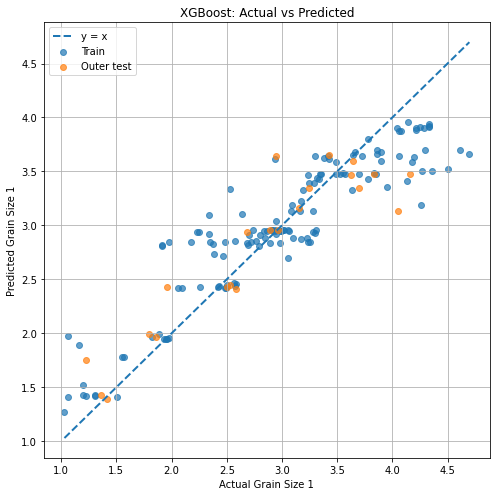

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual Grain Size 1")
plt.ylabel("Predicted Grain Size 1")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


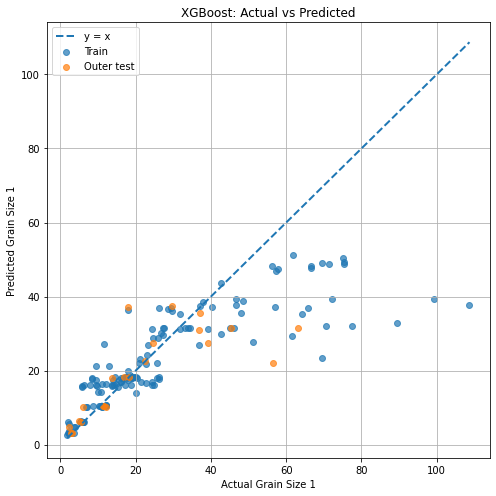

In [9]:
# ============================================================
# 10. Plot actual versus predicted values on the original scale
# ============================================================

# Convert log-transformed values back to the original scale
y_train_original = np.expm1(
    np.asarray(y_train)
)

y_test_original = np.expm1(
    np.asarray(y_test)
)

y_train_pred_original = np.expm1(
    np.asarray(y_train_pred)
)

y_test_pred_original = np.expm1(
    np.asarray(y_test_pred)
)


plt.figure(figsize=(7, 7))

plt.scatter(
    y_train_original,
    y_train_pred_original,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test_original,
    y_test_pred_original,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train_original.min(),
    y_test_original.min(),
    y_train_pred_original.min(),
    y_test_pred_original.min()
)

max_val = max(
    y_train_original.max(),
    y_test_original.max(),
    y_train_pred_original.max(),
    y_test_pred_original.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual Grain Size 1")
plt.ylabel("Predicted Grain Size 1")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_Grain1.pkl")

# Save selected feature names
np.save(
    "model/end to end/Grain1_selected_features.npy",
    np.array(selected_features)
)

# Predictions on log scale
y_train_pred_log = model.predict(
    X_train[selected_features]
)

y_test_pred_log = model.predict(
    X_test[selected_features]
)

# Convert actual and predicted values to the original scale
y_train_original = np.expm1(
    np.asarray(y_train)
)

y_test_original = np.expm1(
    np.asarray(y_test)
)

y_train_pred_original = np.expm1(
    y_train_pred_log
)

y_test_pred_original = np.expm1(
    y_test_pred_log
)

# Save scatter plot data on the original scale
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL].to_numpy(),
        "dataset": "Train",
        "actual": y_train_original,
        "predicted": y_train_pred_original
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL].to_numpy(),
        "dataset": "Test",
        "actual": y_test_original,
        "predicted": y_test_pred_original
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/Grain1_scatter_data_original.csv",
    index=False
)

print("Model, selected features, and original-scale scatter data were saved.")

Model, selected features, and original-scale scatter data were saved.


## 2.a1

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/a1_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/a1_air_test.csv"
)

TARGET_COL = "a_1"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



# y_train_raw = train_data[TARGET_COL].astype(float)
# y_test_raw = test_data[TARGET_COL].astype(float)

# y_train = np.log1p(y_train_raw)
# y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (138, 25)
Outer-test shape: (22, 25)
Training compounds: 135
Outer-test compounds: 21


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=500,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(16)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 16
Selected features: ['C_CR', 'AB_EN', 'AB_AR', 'C_FIE', 'AB_CR', 'C_AN', 'C_SIE', 'AB_EA', 'AB_AN', 'AB_AW', 'AB_SIE', 'C_D', 'AB_Nd', 'AB_FIE', 'C_AW', 'AB_EC']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.08,
    max_depth=3,
    min_child_weight=5,
    gamma=0.5,
    subsample=0.3,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 0.7751 ± 0.4402
RMSE: 0.8341 ± 0.2817
MAE: 0.4578 ± 0.1199
R2: 0.7702 ± 0.1336


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.1462  RMSE: 0.3824  MAE: 0.2039  R2: 0.9592

Outer test:
MSE: 0.7416  RMSE: 0.8612  MAE: 0.3833  R2: 0.8578


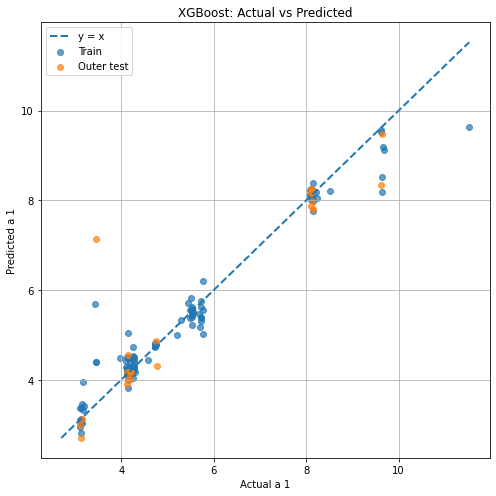

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual a 1")
plt.ylabel("Predicted a 1")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_a1.pkl")

# Save selected feature names
np.save(
    "model/end to end/a1_selected_features.npy",
    np.array(selected_features)
)

# Predictions on the original target scale
y_train_pred_log = model.predict(X_train[selected_features])
y_test_pred_log = model.predict(X_test[selected_features])

# Save scatter plot data
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL],
        "dataset": "Train",
        "actual": y_train,
        "predicted": y_train_pred_log
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL],
        "dataset": "Test",
        "actual": y_test,
        "predicted": y_test_pred_log
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/a1_scatter_data.csv",
    index=False
)

print("Model, selected features, and scatter data were saved.")

Model, selected features, and scatter data were saved.


## 3. b1

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/b1_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/b1_air_test.csv"
)

TARGET_COL = "b_1"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



# y_train_raw = train_data[TARGET_COL].astype(float)
# y_test_raw = test_data[TARGET_COL].astype(float)

# y_train = np.log1p(y_train_raw)
# y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (138, 25)
Outer-test shape: (22, 25)
Training compounds: 135
Outer-test compounds: 21


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=200,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(15)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 15
Selected features: ['C_VR', 'AB_EN', 'AB_AR', 'AB_EC', 'AB_CR', 'AB_AW', 'C_SIE', 'C_AN', 'C_FIE', 'AB_Nd', 'AB_AN', 'AB_FIE', 'AB_EA', 'C_CR', 'AB_SIE']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=850,
    learning_rate=0.09,
    max_depth=6,
    min_child_weight=5,
    gamma=0.4,
    subsample=0.3,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    random_state=2027,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 1.7056 ± 1.6487
RMSE: 1.1852 ± 0.5484
MAE: 0.5628 ± 0.2185
R2: 0.6018 ± 0.2593


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.1304  RMSE: 0.3611  MAE: 0.1864  R2: 0.9660

Outer test:
MSE: 0.8877  RMSE: 0.9422  MAE: 0.4499  R2: 0.8298


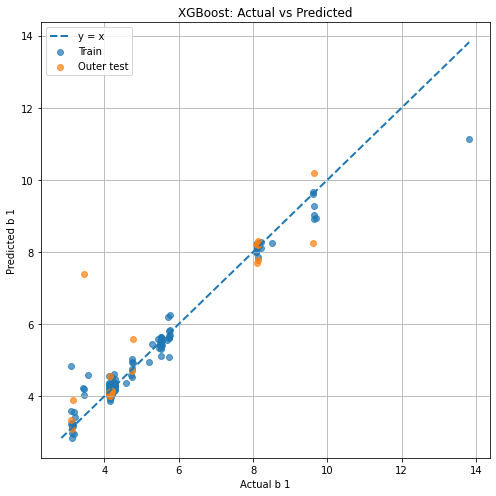

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual b 1")
plt.ylabel("Predicted b 1")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_b1.pkl")

# Save selected feature names
np.save(
    "model/end to end/b1_selected_features.npy",
    np.array(selected_features)
)

# Predictions on the original target scale
y_train_pred_log = model.predict(X_train[selected_features])
y_test_pred_log = model.predict(X_test[selected_features])

# Save scatter plot data
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL],
        "dataset": "Train",
        "actual": y_train,
        "predicted": y_train_pred_log
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL],
        "dataset": "Test",
        "actual": y_test,
        "predicted": y_test_pred_log
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/b1_scatter_data.csv",
    index=False
)

print("Model, selected features, and scatter data were saved.")

Model, selected features, and scatter data were saved.


## 4.c1

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
# ============================================================
# 1. Load the fixed training and outer-test datasets
# ============================================================

train_data = pd.read_csv(
    "data/end_to_end_split/structure/c1_train_pool.csv"
)

test_data = pd.read_csv(
    "data/end_to_end_split/structure/c1_air_test.csv"
)

TARGET_COL = "c_1"
GROUP_COL = "compound"

In [3]:
# ============================================================
# 2. Define features, target, and groups
# ============================================================

X_train = train_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_train = train_data[TARGET_COL].astype(float)

X_test = test_data.drop(
    columns=[TARGET_COL, GROUP_COL]
)

y_test = test_data[TARGET_COL].astype(float)

groups_train = train_data[GROUP_COL]



# y_train_raw = train_data[TARGET_COL].astype(float)
# y_test_raw = test_data[TARGET_COL].astype(float)

# y_train = np.log1p(y_train_raw)
# y_test = np.log1p(y_test_raw)


print("Training shape:", X_train.shape)
print("Outer-test shape:", X_test.shape)

print(
    "Training compounds:",
    train_data[GROUP_COL].nunique()
)

print(
    "Outer-test compounds:",
    test_data[GROUP_COL].nunique()
)


Training shape: (138, 25)
Outer-test shape: (22, 25)
Training compounds: 135
Outer-test compounds: 21


In [4]:
# ============================================================
# 3. Feature selection
# ============================================================

fs_est = XGBRegressor(
    n_estimators=200,
    random_state=42,
    verbosity=0,
    tree_method="hist"
)

fs_est.fit(
    X_train,
    y_train
)

importances = fs_est.feature_importances_

feat_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": importances
}).sort_values(
    "importance",
    ascending=False
)

selected_features = (
    feat_df
    .head(10)["feature"]
    .tolist()
)

print("Number of selected features:", len(selected_features))
print("Selected features:", selected_features)

Number of selected features: 10
Selected features: ['C_AN', 'AB_EC', 'AB_FIE', 'AB_AN', 'AB_D', 'AB_AR', 'C_SIE', 'C_D', 'AB_Nd', 'C_AW']


In [5]:
# ============================================================
# 4. Define the regression model
# ============================================================

model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=4,
    gamma=0.5,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=8,
    random_state=42,
    n_jobs=1,
    tree_method='hist',
    verbosity=0
)


In [6]:
# 5. Evaluation function
# ============================================================

def evaluate_regression(y_true, y_pred):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return (
        f"MSE: {mse:.4f}  "
        f"RMSE: {rmse:.4f}  "
        f"MAE: {mae:.4f}  "
        f"R2: {r2:.4f}"
    )

In [7]:
# ============================================================
# 6. Grouped five-fold cross-validation
# ============================================================

group_cv = GroupKFold(
    n_splits=5
)

scoring = {
    "MSE": "neg_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2"
}

cv_results = cross_validate(
    model,
    X_train[selected_features],
    y_train,
    groups=groups_train,
    cv=group_cv,
    scoring=scoring,
    return_train_score=False
)

fold_mse = -cv_results["test_MSE"]
fold_rmse = np.sqrt(fold_mse)
fold_mae = -cv_results["test_MAE"]
fold_r2 = cv_results["test_R2"]

print("\n5-fold grouped CV:")

print(
    f"MSE: {fold_mse.mean():.4f} "
    f"± {fold_mse.std():.4f}"
)

print(
    f"RMSE: {fold_rmse.mean():.4f} "
    f"± {fold_rmse.std():.4f}"
)

print(
    f"MAE: {fold_mae.mean():.4f} "
    f"± {fold_mae.std():.4f}"
)

print(
    f"R2: {fold_r2.mean():.4f} "
    f"± {fold_r2.std():.4f}"
)


5-fold grouped CV:
MSE: 0.4093 ± 0.2616
RMSE: 0.6036 ± 0.2121
MAE: 0.2762 ± 0.0872
R2: 0.9245 ± 0.0524


In [8]:
# ============================================================
# 7. Train the final model
# ============================================================

model.fit(
    X_train[selected_features],
    y_train
)


# ============================================================
# 8. Predict the training and outer-test datasets
# ============================================================

y_train_pred = model.predict(
    X_train[selected_features]
)

y_test_pred = model.predict(
    X_test[selected_features]
)

print("\nTrain:")
print(
    evaluate_regression(
        y_train,
        y_train_pred
    )
)

print("\nOuter test:")
print(
    evaluate_regression(
        y_test,
        y_test_pred
    )
)


Train:
MSE: 0.0598  RMSE: 0.2445  MAE: 0.1248  R2: 0.9911

Outer test:
MSE: 0.1755  RMSE: 0.4189  MAE: 0.1584  R2: 0.9826


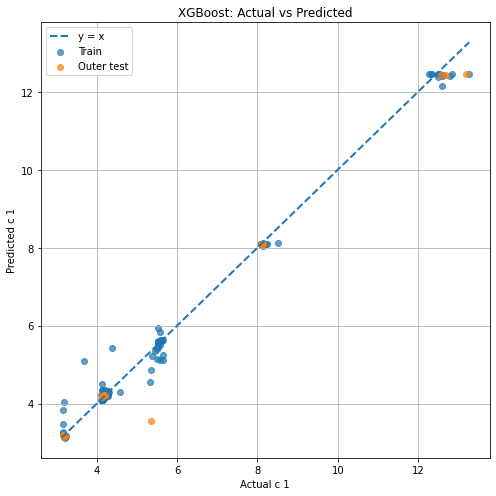

In [9]:
# ============================================================
# 9. Plot actual versus predicted values
# ============================================================

plt.figure(figsize=(7, 7))

plt.scatter(
    y_train,
    y_train_pred,
    label="Train",
    alpha=0.7
)

plt.scatter(
    y_test,
    y_test_pred,
    label="Outer test",
    alpha=0.7
)

min_val = min(
    y_train.min(),
    y_test.min(),
    y_train_pred.min(),
    y_test_pred.min()
)

max_val = max(
    y_train.max(),
    y_test.max(),
    y_train_pred.max(),
    y_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    label="y = x"
)

plt.xlabel("Actual c 1")
plt.ylabel("Predicted c 1")
plt.title("XGBoost: Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
os.makedirs("model/end to end", exist_ok=True)

# Save model
joblib.dump(model, "model/end to end/xgb_c1.pkl")

# Save selected feature names
np.save(
    "model/end to end/c1_selected_features.npy",
    np.array(selected_features)
)

# Predictions on the original target scale
y_train_pred_log = model.predict(X_train[selected_features])
y_test_pred_log = model.predict(X_test[selected_features])

# Save scatter plot data
scatter_data = pd.concat([
    pd.DataFrame({
        "compound": train_data[GROUP_COL],
        "dataset": "Train",
        "actual": y_train,
        "predicted": y_train_pred_log
    }),
    pd.DataFrame({
        "compound": test_data[GROUP_COL],
        "dataset": "Test",
        "actual": y_test,
        "predicted": y_test_pred_log
    })
], ignore_index=True)

scatter_data.to_csv(
    "model/end to end/c1_scatter_data.csv",
    index=False
)

print("Model, selected features, and scatter data were saved.")

Model, selected features, and scatter data were saved.


In [2]:
import sys
import numpy as np
import pandas as pd
import sklearn
import xgboost

print("Python:", sys.version.split()[0])
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("Executable:", sys.executable)

Python: 3.6.13
numpy: 1.19.5
pandas: 1.1.5
scikit-learn: 0.24.2
xgboost: 1.5.2
Executable: D:\app\miniconda\envs\p110p36\python.exe
